<a href="https://colab.research.google.com/github/brucenguyen0302-code/last-mile-route-duration/blob/main/notebooks/AT1_II_route_duration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Last-Mile Delivery Route Duration

**42172 Introduction to Artificial Intelligence — AT1, Example II (regression)**

Delivery routes are planned by software, but drivers often change the planned stop order, so the time a route
really takes can differ a lot from the plan. This notebook builds regression models that predict the **actual
duration of a delivery route (in minutes)** using only information that is known before the route starts.

**Data:** Konovalenko, A., Hvattum, L. M., & Iversen, K. A. H. (2024). *Last-mile delivery route deviations
dataset: Planned vs. actual routes* [Data set]. Mendeley Data. https://doi.org/10.17632/kkwgfvmtxn.1

**Notebook structure**
1. Setup
2. Load the dataset
3. First look at the data
4. Check the dataset against its description
5. Build one row per route
6. Clean the route table
7. Explore the route table
8. Chronological train, validation and test split
9. Baseline models
10. Model development and tuning
11. Final evaluation on the test set
12. Statistical comparison
13. Figures
14. Predicting unseen routes

## 1. Setup

Mount Google Drive, fix one random seed so every run gives the same results, and create the project folders
for data, results and figures.

In [43]:
from google.colab import drive
drive.mount('/content/gdrive')

import os, glob, random, sys
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE = '/content/gdrive/MyDrive/IntroToAI/AT1_II'
DATA_DIR = os.path.join(BASE, 'data')
RESULTS_DIR = os.path.join(BASE, 'results')
FIG_DIR = os.path.join(BASE, 'figures')
for folder in (DATA_DIR, RESULTS_DIR, FIG_DIR):
    os.makedirs(folder, exist_ok=True)

print('Python :', sys.version.split()[0])
print('pandas :', pd.__version__)
print('numpy  :', np.__version__)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Python : 3.13.15
pandas : 2.2.3
numpy  : 2.1.3


## 2. Load the dataset

The data file is `routes_performance.xlsx`. The notebook searches Google Drive for it by name instead of using a
fixed path. Reading a 20 MB Excel file is slow, so the first run saves a fast copy (a pickle file) in the data
folder and later runs load that copy instead.

In [44]:
DATA_FILE = 'routes_performance.xlsx'
CACHE_FILE = os.path.join(DATA_DIR, 'routes_performance_raw.pkl')

if os.path.exists(CACHE_FILE):
    raw = pd.read_pickle(CACHE_FILE)
    print('Loaded from cache:', CACHE_FILE)
else:
    matches = glob.glob(f'/content/gdrive/MyDrive/**/{DATA_FILE}', recursive=True)
    assert matches, f'{DATA_FILE} not found anywhere in Google Drive'
    DATA_PATH = matches[0]
    print('Reading:', DATA_PATH)
    raw = pd.read_excel(DATA_PATH, sheet_name=0)
    raw.to_pickle(CACHE_FILE)
    print('Saved cache:', CACHE_FILE)

print(f'Rows    : {len(raw):,}')
print(f'Columns : {raw.shape[1]}')

Loaded from cache: /content/gdrive/MyDrive/IntroToAI/AT1_II/data/routes_performance_raw.pkl
Rows    : 249,231
Columns : 16


## 3. First look at the data

Each row is one visit to a stop on a route. This cell shows the first rows, counts missing values, and lists
each column's type, number of unique values and range.

In [45]:
display(raw.head(10))

print('Missing values in the whole table:', int(raw.isna().sum().sum()))

summary = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'unique values': raw.nunique(),
    'min': raw.min(numeric_only=True),
    'max': raw.max(numeric_only=True),
}).reindex(raw.columns)
pd.set_option('display.float_format', '{:,.2f}'.format)
display(summary)

,Route ID,Driver ID,Stop ID,Address ID,Week ID,Country,Day of Week,IndexP,IndexA,Arrived Time,Earliest Time,Latest Time,DistanceP,DistanceA,Depot,Delivery
0,0,0,0,0,0,1,Monday,0,0,42.27,0.00,360.00,0.00,0.00,1,0
1,0,0,1,1,0,1,Tuesday,1,4,332.79,240.00,480.00,16.33,16.33,0,1
2,0,0,2,2,0,1,Tuesday,2,5,332.96,120.00,540.00,0.37,0.37,0,1
3,0,0,3,3,0,1,Monday,3,2,244.99,60.00,540.00,2.49,0.00,0,1
4,0,0,4,3,0,1,Monday,4,1,244.85,60.00,540.00,0.00,13.94,0,1
5,0,0,0,0,0,1,Monday,5,3,272.12,0.00,360.00,13.94,13.94,1,0
6,0,0,1,1,0,1,Tuesday,6,6,373.55,240.00,480.00,16.33,0.37,0,1
7,1,1,0,0,0,1,Monday,0,0,64.86,0.00,360.00,0.00,0.00,1,0
8,1,1,5,4,0,1,Monday,1,2,75.52,120.00,540.00,16.77,11.92,0,1
9,1,1,6,5,0,1,Tuesday,2,5,324.37,120.00,540.00,0.08,0.73,0,1


Missing values in the whole table: 0


,dtype,unique values,min,max
Route ID,int64,19647,0.00,"19,646.00"
Driver ID,int64,400,0.00,399.00
Stop ID,int64,13125,0.00,"13,124.00"
Address ID,int64,10864,0.00,"10,863.00"
Week ID,int64,32,0.00,31.00
Country,int64,2,0.00,1.00
Day of Week,object,7,NaN,NaN
IndexP,int64,36,0.00,35.00
IndexA,int64,36,0.00,35.00
Arrived Time,float64,197396,0.00,"12,814,321.85"


## 4. Check the dataset against its description

The assertions below stop the notebook if the file is not the one expected, so any later change to the data is
caught straight away.

*Note:* the data paper reports 19,497 routes, but this file contains 19,647.

In [46]:
n_routes = raw['Route ID'].nunique()
n_drivers = raw['Driver ID'].nunique()
n_weeks = raw['Week ID'].nunique()

print(f'Routes    : {n_routes:,}')
print(f'Drivers   : {n_drivers}')
print(f"Weeks     : {n_weeks} (Week ID {raw['Week ID'].min()} to {raw['Week ID'].max()})")
print(f"Countries : {sorted(raw['Country'].unique().tolist())}")
print()
print(raw['Day of Week'].value_counts())

assert raw.shape == (249231, 16)
assert n_drivers == 400 and n_weeks == 32
assert raw.isna().sum().sum() == 0
assert raw['Route ID'].is_monotonic_increasing, 'Routes are expected in date order'
print('\nAll checks passed.')

Routes    : 19,647
Drivers   : 400
Weeks     : 32 (Week ID 0 to 31)
Countries : [0, 1]

Day of Week
Tuesday      53465
Monday       49013
Thursday     47627
Wednesday    47622
Friday       42736
Saturday      6536
Sunday        2232
Name: count, dtype: int64

All checks passed.


## 5. Build one row per route

The raw table has one row per stop visit, but the prediction is made for a whole route, so the stop rows are
grouped into one row per route.

**Target.** The route duration is the time between the first and the last recorded arrival in the route:

$$\text{duration\_min} = \max(\text{Arrived Time}) - \min(\text{Arrived Time})$$

**Features.** To avoid data leakage, the features only use information that the planner already has before the
driver leaves the depot: the planned stop sequence (`IndexP`), the planned leg distances (`DistanceP`), the
customer time windows, the stop types, the country, the weekday and the driver's history. The columns that record
what actually happened (`IndexA`, `DistanceA`, `Arrived Time`) are only used to build the target and the
data-quality flags, never as model inputs.

| Feature | Meaning |
|---|---|
| `n_stops` | Number of customer stop visits |
| `n_depot_visits` | Number of times the plan passes through the depot |
| `n_pickups` | Number of pickup stops |
| `n_addresses` | Number of different customer addresses |
| `planned_km` | Total planned driving distance |
| `max_leg_km` | Longest single planned leg |
| `first_leg_km` | Planned distance from the depot to the first customer |
| `earliest_start` | Earliest opening time of any customer time window |
| `latest_end` | Latest closing time of any customer time window |
| `mean_window` | Average customer time-window width |
| `min_window` | Narrowest customer time window |
| `country` | Country of operation (0 or 1) |
| `weekday` | Day of the week of the first planned stop |
| `driver_prior_routes` | Number of routes the driver completed in earlier rows of the data |

Two quality flags are also created for the cleaning step: whether the arrival times increase along the actual
driving order, and whether the actual route starts at the depot.

In [47]:
stops = raw.copy()
stops['is_stop'] = (stops['Depot'] == 0).astype(int)
stops['is_pickup'] = ((stops['Depot'] == 0) & (stops['Delivery'] == 0)).astype(int)
stops['window_width'] = stops['Latest Time'] - stops['Earliest Time']

planned = stops.sort_values(['Route ID', 'IndexP'])
actual = stops.sort_values(['Route ID', 'IndexA'])
by_plan = planned.groupby('Route ID')
by_actual = actual.groupby('Route ID')
by_customer = planned[planned['is_stop'] == 1].groupby('Route ID')

routes = pd.DataFrame({
    'week_id': by_plan['Week ID'].first(),
    'driver_id': by_plan['Driver ID'].first(),
    'country': by_plan['Country'].first(),
    'weekday': by_plan['Day of Week'].first(),
    'n_stops': by_plan['is_stop'].sum(),
    'n_depot_visits': by_plan['Depot'].sum(),
    'n_pickups': by_plan['is_pickup'].sum(),
    'n_addresses': by_customer['Address ID'].nunique(),
    'planned_km': by_plan['DistanceP'].sum(),
    'max_leg_km': by_plan['DistanceP'].max(),
    'first_leg_km': by_customer['DistanceP'].first(),
    'earliest_start': by_customer['Earliest Time'].min(),
    'latest_end': by_customer['Latest Time'].max(),
    'mean_window': by_customer['window_width'].mean(),
    'min_window': by_customer['window_width'].min(),
    'duration_min': by_actual['Arrived Time'].max() - by_actual['Arrived Time'].min(),
    'flag_in_order': by_actual['Arrived Time'].apply(lambda t: t.is_monotonic_increasing),
    'flag_depot_first': by_actual['Depot'].first() == 1,
}).reset_index()

routes['driver_prior_routes'] = routes.groupby('driver_id').cumcount()

print(f'Stop rows : {len(stops):,}')
print(f'Routes    : {len(routes):,}')
print(f'Columns   : {routes.shape[1]}')
display(routes.head())

Stop rows : 249,231
Routes    : 19,647
Columns   : 20


,Route ID,week_id,driver_id,country,weekday,n_stops,n_depot_visits,n_pickups,n_addresses,planned_km,max_leg_km,first_leg_km,earliest_start,latest_end,mean_window,min_window,duration_min,flag_in_order,flag_depot_first,driver_prior_routes
0,0,0,0,1,Monday,5,2,0,3.00,49.47,16.33,16.33,60.00,540.00,372.00,240.00,331.28,True,True,0
1,1,0,1,1,Monday,6,1,0,6.00,33.27,16.77,16.77,120.00,540.00,360.00,180.00,306.53,True,True,0
2,2,0,2,1,Monday,6,1,0,6.00,12.12,8.22,8.22,120.00,600.00,320.00,180.00,362.99,True,True,0
3,3,0,3,1,Monday,9,1,0,8.00,19.04,14.69,14.69,120.00,600.00,306.67,120.00,254.09,True,True,0
4,4,0,4,1,Monday,7,1,0,7.00,20.63,10.36,10.36,240.00,780.00,334.29,240.00,160.75,True,True,0


### 5.1 Check the route table

The assertions confirm that no stop row was lost or double-counted when the rows were grouped, and that the
routes are still in date order. The summary of the target and the flags shows how much of the data has quality
problems before any cleaning.

In [48]:
assert routes['Route ID'].is_unique
assert len(routes) == raw['Route ID'].nunique()
assert (routes['n_stops'] + routes['n_depot_visits']).sum() == len(raw)
assert routes['Route ID'].is_monotonic_increasing and routes['week_id'].is_monotonic_increasing

print('Route duration (minutes), before cleaning:')
display(routes['duration_min'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame().T)

print(f"Arrival times in driving order : {routes['flag_in_order'].mean():.1%}")
print(f"Actual route starts at depot   : {routes['flag_depot_first'].mean():.1%}")
print(f"Routes with no customer stops  : {(routes['n_stops'] == 0).sum()}")
print(f"Routes with zero duration      : {(routes['duration_min'] == 0).sum()}")
print(f"Routes longer than 24 hours    : {(routes['duration_min'] > 1440).sum()}")

Route duration (minutes), before cleaning:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
duration_min,"19,647.00",451.77,"1,351.41",0.00,0.00,5.76,267.28,354.16,444.05,624.80,"2,787.85","57,552.85"


Arrival times in driving order : 92.3%
Actual route starts at depot   : 94.7%
Routes with no customer stops  : 30
Routes with zero duration      : 738
Routes longer than 24 hours    : 390


## 6. Clean the route table

Section 5.1 showed that some routes contain recording errors: arrival times out of order, routes that do not
start at the depot, durations of zero and durations of several days. These routes do not describe a real delivery
shift, so they are removed. Each rule is based on a physical or legal limit rather than on how unusual a value
looks, so genuine long or short routes are kept.

| Rule | A route is kept only if… | Reason |
|---|---|---|
| R1 | it has at least one customer stop | A route that only visits the depot is not a delivery route. |
| R2 | its arrival times increase along the actual driving order | A driver cannot arrive at a later stop before an earlier one, so the timestamps are corrupted. |
| R3 | its actual driving order starts at the depot | The duration is measured from the depot departure; without it the start time is unknown. |
| R4 | all customer time windows open and close within one day (0–1,440 minutes) | A same-day delivery window cannot close days later; values such as 12.8 million minutes are recording errors. |
| R5 | its duration is at most 780 minutes (13 hours) | Workers in Norway and Denmark must have at least 11 consecutive hours of rest in every 24 hours (Directive 2003/88/EC), so one shift cannot span more than 13 hours. |
| R6 | its implied average speed (planned km ÷ duration) is at most 130 km/h | 130 km/h is the highest legal speed limit in either country, so a faster route is physically impossible. |
| R7 | it takes at least one minute per customer stop | Handing over or collecting a parcel takes time, so a shorter route cannot have been driven. |

The rules are applied in order, and the log records how many routes each rule removes. The same rules are applied
to every week of data before the split, because they describe whether a record is valid, not how the model is
trained.

In [49]:
speed_kmh = routes['planned_km'] / (routes['duration_min'] / 60)

rules = {
    'R1 has customer stops': routes['n_stops'] > 0,
    'R2 arrivals in driving order': routes['flag_in_order'],
    'R3 starts at the depot': routes['flag_depot_first'],
    'R4 time windows within one day': (routes['earliest_start'] <= 1440) & (routes['latest_end'] <= 1440),
    'R5 duration at most 13 hours': routes['duration_min'] <= 780,
    'R6 average speed at most 130 km/h': (routes['duration_min'] > 0) & (speed_kmh <= 130),
    'R7 at least 1 minute per stop': routes['duration_min'] >= routes['n_stops'],
}

keep = pd.Series(True, index=routes.index)
log = []
for name, passed in rules.items():
    passed = passed.fillna(False).astype(bool)
    removed = int((keep & ~passed).sum())
    keep &= passed
    log.append({'rule': name, 'failed (any order)': int((~passed).sum()),
                'removed at this step': removed, 'routes left': int(keep.sum())})

cleaning_log = pd.DataFrame(log)
cleaning_log.to_csv(os.path.join(RESULTS_DIR, 'cleaning_log.csv'), index=False)
display(cleaning_log)

routes_clean = routes.loc[keep].drop(columns=['flag_in_order', 'flag_depot_first']).reset_index(drop=True)
print(f'Routes kept    : {len(routes_clean):,} of {len(routes):,} ({len(routes_clean) / len(routes):.1%})')
print(f'Routes removed : {len(routes) - len(routes_clean):,}')

,rule,failed (any order),removed at this step,routes left
0,R1 has customer stops,30,30,19617
1,R2 arrivals in driving order,1513,1509,18108
2,R3 starts at the depot,1045,1020,17088
3,R4 time windows within one day,351,217,16871
4,R5 duration at most 13 hours,604,416,16455
5,R6 average speed at most 130 km/h,1002,405,16050
6,R7 at least 1 minute per stop,959,2,16048


Routes kept    : 16,048 of 19,647 (81.7%)
Routes removed : 3,599


### 6.1 Check the cleaned table

The assertions confirm that every rule holds in the cleaned table, that no values are missing, and that every
week still has enough routes for a chronological split. The summary shows the target after cleaning.

In [50]:
assert routes_clean.isna().sum().sum() == 0
assert routes_clean['duration_min'].between(1, 780).all()
assert (routes_clean['duration_min'] >= routes_clean['n_stops']).all()
assert routes_clean['latest_end'].le(1440).all() and routes_clean['earliest_start'].le(1440).all()
assert routes_clean['Route ID'].is_monotonic_increasing

print('Route duration (minutes), after cleaning:')
display(routes_clean['duration_min'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame().T)

per_week = routes_clean.groupby('week_id').size()
print(f'Routes per week: min {per_week.min()}, median {per_week.median():.0f}, max {per_week.max()}')
assert per_week.min() >= 300

routes_clean.to_pickle(os.path.join(DATA_DIR, 'routes_clean.pkl'))
print('Saved:', os.path.join(DATA_DIR, 'routes_clean.pkl'))

Route duration (minutes), after cleaning:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
duration_min,"16,048.00",358.26,120.11,2.16,94.70,167.62,277.04,352.98,434.49,568.16,664.82,776.73


Routes per week: min 350, median 491, max 617
Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/data/routes_clean.pkl


## 7. Explore the route table

This section looks at the cleaned routes before any modelling: how the target is distributed, which planned
features move with it, whether the two countries and the weekdays behave differently, and whether route
durations drift over the 32 weeks. The last point matters because the models will be trained on earlier weeks and
tested on later ones.

All figures share one style: a colour-vision-deficiency-safe palette (blue `#2a78d6`, orange `#eb6834`, green
`#1baf7a`), light grid lines, direct labels on the data, and 200 dpi PNG copies saved to the figures folder.

In [51]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

BLUE, ORANGE, GREEN = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#1f1f1f', '#6b6b6b', '#e6e6e6'

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.titlelocation': 'left',
    'axes.labelcolor': INK,
    'axes.edgecolor': GRID,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'legend.frameon': False,
})

def save_figure(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path)
    plt.show()
    print('Saved:', path)

FEATURES_NUM = ['n_stops', 'n_depot_visits', 'n_pickups', 'n_addresses', 'planned_km', 'max_leg_km',
                'first_leg_km', 'earliest_start', 'latest_end', 'mean_window', 'min_window',
                'driver_prior_routes']
FEATURES_CAT = ['country', 'weekday']
TARGET = 'duration_min'
print(f'{len(FEATURES_NUM)} numeric and {len(FEATURES_CAT)} categorical features')

12 numeric and 2 categorical features


### 7.1 Distribution of route duration

A histogram of the target shows its typical value and spread, and whether it is skewed enough to need a
transformation before modelling.

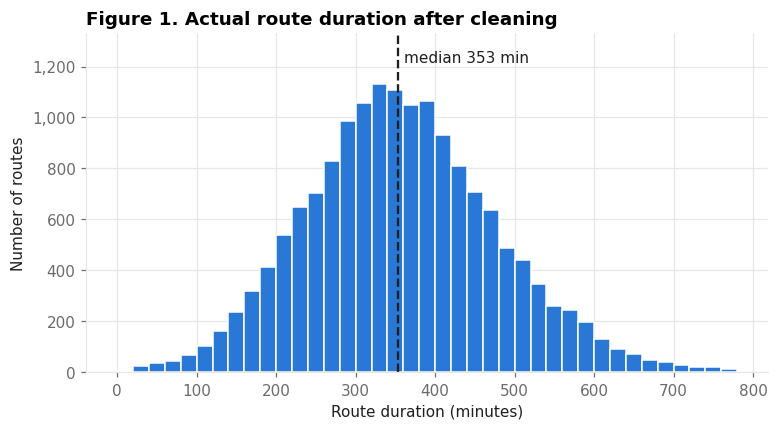

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig01_duration_distribution.png
Skewness : 0.24
Median   : 353.0 min (5.9 h)
IQR      : 277.0 to 434.5 min


In [52]:
y_all = routes_clean[TARGET]
median_all = y_all.median()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_all, bins=np.arange(0, 800, 20), color=BLUE, edgecolor='white', linewidth=1)
ax.axvline(median_all, color=INK, linewidth=1.5, linestyle='--')
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
ax.text(median_all + 8, ax.get_ylim()[1] * 0.95, f'median {median_all:.0f} min', color=INK, va='top')
ax.set_title('Figure 1. Actual route duration after cleaning')
ax.set_xlabel('Route duration (minutes)')
ax.set_ylabel('Number of routes')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:,.0f}'))
save_figure(fig, 'fig01_duration_distribution.png')

print(f'Skewness : {y_all.skew():.2f}')
print(f'Median   : {median_all:.1f} min ({median_all / 60:.1f} h)')
print(f'IQR      : {y_all.quantile(.25):.1f} to {y_all.quantile(.75):.1f} min')

### 7.2 Which planned features move with duration?

Spearman's rank correlation measures how consistently duration rises or falls with each numeric feature, without
assuming a straight-line relationship. It is used here only to describe the data; the models themselves decide
how to use each feature.

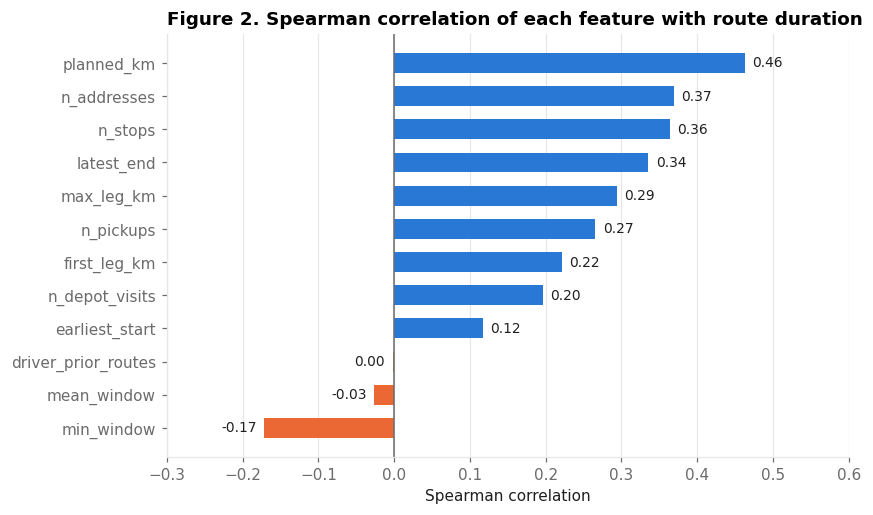

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig02_feature_correlation.png


,spearman
planned_km,0.46
n_addresses,0.37
n_stops,0.36
latest_end,0.34
max_leg_km,0.29
n_pickups,0.27
first_leg_km,0.22
n_depot_visits,0.20
earliest_start,0.12
driver_prior_routes,-0.00


In [53]:
spearman = (routes_clean[FEATURES_NUM + [TARGET]]
            .corr(method='spearman')[TARGET]
            .drop(TARGET)
            .sort_values())

fig, ax = plt.subplots(figsize=(8, 5))
colors = [BLUE if v >= 0 else ORANGE for v in spearman]
ax.barh(spearman.index, spearman.values, color=colors, height=0.6)
ax.axvline(0, color=MUTED, linewidth=1)
for i, v in enumerate(spearman.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{round(v, 2) + 0.0:.2f}', va='center',
            ha='left' if v >= 0 else 'right', color=INK, fontsize=9)
ax.set_xlim(-0.3, 0.6)
ax.grid(axis='y', visible=False)
ax.set_title('Figure 2. Spearman correlation of each feature with route duration')
ax.set_xlabel('Spearman correlation')
save_figure(fig, 'fig02_feature_correlation.png')

display(spearman.sort_values(ascending=False).round(3).to_frame('spearman'))

### 7.3 Duration against planned distance and number of stops

The two strongest features are plotted against duration. With about 16,000 routes, individual points would
overlap, so each panel shows how many routes fall in each cell (darker = more routes), with the median duration of each
band drawn on top.

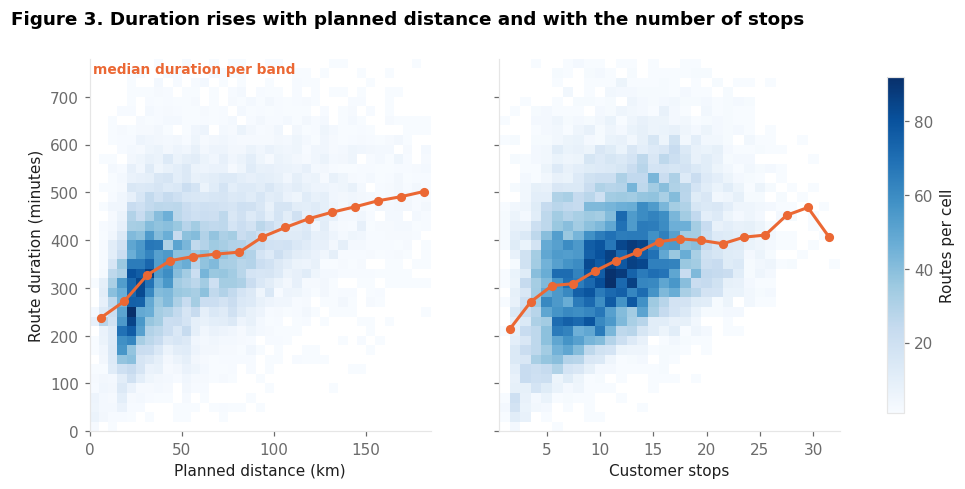

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig03_duration_vs_distance_stops.png


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)

km_cap = routes_clean['planned_km'].quantile(0.99)
y_bins = np.arange(0, 800, 20)
panels = [
    (axes[0], 'planned_km', 'Planned distance (km)', np.arange(0, km_cap + 5, 5), np.arange(0, km_cap + 10, 12.5)),
    (axes[1], 'n_stops', 'Customer stops', np.arange(0.5, 33.5, 1), np.arange(0.5, 33.5, 2)),
]
for ax, col, label, x_bins, band_edges in panels:
    data = routes_clean[routes_clean[col] <= x_bins[-1]]
    counts, _, _, image = ax.hist2d(data[col], data[TARGET], bins=[x_bins, y_bins], cmap='Blues', cmin=1)
    band_median = data.groupby(pd.cut(data[col], band_edges), observed=True)[TARGET].median()
    centres = [interval.mid for interval in band_median.index]
    ax.plot(centres, band_median.values, color=ORANGE, linewidth=2, marker='o', markersize=5)
    ax.set_xlabel(label)
    ax.grid(False)

axes[0].text(2, 750, 'median duration per band', color=ORANGE, fontsize=9, fontweight='bold')
axes[0].set_ylabel('Route duration (minutes)')
fig.suptitle('Figure 3. Duration rises with planned distance and with the number of stops',
             x=0.06, ha='left', fontweight='bold', fontsize=12)
fig.colorbar(image, ax=axes, label='Routes per cell', shrink=0.9)
save_figure(fig, 'fig03_duration_vs_distance_stops.png')

### 7.4 Differences between countries and weekdays

The two categorical features are summarised as tables of route counts and median durations.

In [55]:
by_country = routes_clean.groupby('country')[TARGET].agg(routes='size', median='median', mean='mean', std='std')
display(by_country.round(1))

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
by_weekday = (routes_clean.groupby('weekday')[TARGET]
              .agg(routes='size', median='median', mean='mean', std='std')
              .reindex(weekday_order))
display(by_weekday.round(1))

,routes,median,mean,std
country,,,,
0,6312,386.00,390.30,116.30
1,9736,331.00,337.50,118.00


,routes,median,mean,std
weekday,,,,
Monday,3155,358.60,360.60,118.40
Tuesday,3330,354.40,359.40,118.10
Wednesday,3163,346.10,350.60,124.30
Thursday,3026,358.30,366.40,123.30
Friday,2497,366.50,373.40,111.30
Saturday,467,329.30,334.30,114.00
Sunday,410,243.70,265.30,102.00


### 7.5 Do durations drift over time?

The models will learn from earlier weeks and be tested on later weeks. If route durations changed over the
32 weeks, the test weeks would be harder to predict than a random sample. The weekly median duration is plotted
separately for each country, with the band showing the middle 50% of routes.

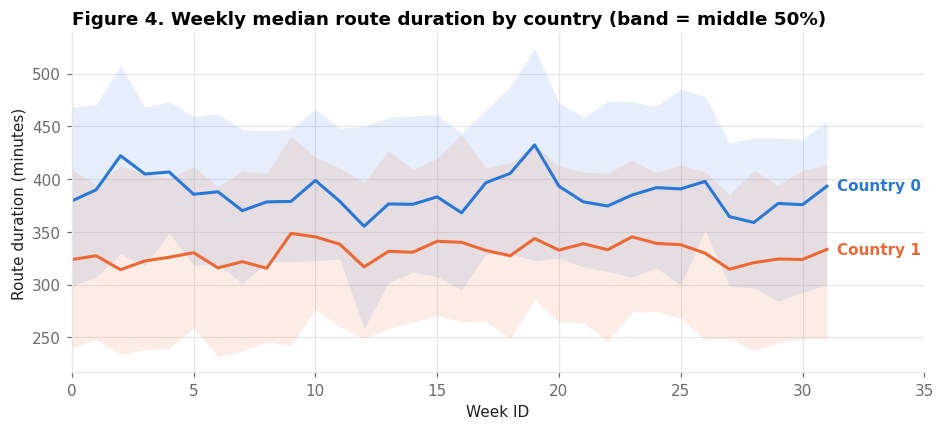

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig04_weekly_duration.png
Median duration, weeks 0-7   : 356.6 min
Median duration, weeks 24-31 : 346.5 min


In [56]:
weekly = routes_clean.groupby(['country', 'week_id'])[TARGET].describe()[['count', '25%', '50%', '75%']]

fig, ax = plt.subplots(figsize=(10, 4))
for country, color in [(0, BLUE), (1, ORANGE)]:
    w = weekly.loc[country]
    ax.fill_between(w.index, w['25%'], w['75%'], color=color, alpha=0.12, linewidth=0)
    ax.plot(w.index, w['50%'], color=color, linewidth=2)
    ax.text(w.index[-1] + 0.4, w['50%'].iloc[-1], f'Country {country}', color=color,
            va='center', fontweight='bold')
ax.set_xlim(0, 35)
ax.set_title('Figure 4. Weekly median route duration by country (band = middle 50%)')
ax.set_xlabel('Week ID')
ax.set_ylabel('Route duration (minutes)')
save_figure(fig, 'fig04_weekly_duration.png')

first, last = routes_clean['week_id'] <= 7, routes_clean['week_id'] >= 24
print(f'Median duration, weeks 0-7   : {routes_clean.loc[first, TARGET].median():.1f} min')
print(f'Median duration, weeks 24-31 : {routes_clean.loc[last, TARGET].median():.1f} min')

## 8. Chronological train, validation and test split

The routes are in date order, so the data is split by week rather than at random. This mirrors real use: a
planning tool is trained on past routes and then predicts routes that happen later. A random split would let the
model learn from routes that happen after the ones it is tested on, which makes the results look better than they
would be in practice.

| Set | Weeks | Purpose |
|---|---|---|
| Training | 0–21 | Fit every model |
| Validation | 22–25 | Compare settings while tuning each model |
| Test | 26–31 | Used once, at the end, to report final results |

The last two test routes are set aside as "future" routes and are only used in Section 14 to show how the final
model would be used on new routes.

`driver_id` itself is not used as a feature: it has 400 levels, and some drivers in the later weeks never appear in
the training weeks. The driver's history is represented by `driver_prior_routes` instead.

In [57]:
FEATURES = FEATURES_NUM + FEATURES_CAT
TRAIN_WEEKS, VAL_WEEKS, TEST_WEEKS = range(0, 22), range(22, 26), range(26, 32)

train_df = routes_clean[routes_clean['week_id'].isin(TRAIN_WEEKS)].reset_index(drop=True)
val_df = routes_clean[routes_clean['week_id'].isin(VAL_WEEKS)].reset_index(drop=True)
test_all = routes_clean[routes_clean['week_id'].isin(TEST_WEEKS)].reset_index(drop=True)
future_df = test_all.tail(2).reset_index(drop=True)
test_df = test_all.iloc[:-2].reset_index(drop=True)

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val, y_val = val_df[FEATURES], val_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

split_summary = pd.DataFrame({
    'weeks': ['0-21', '22-25', '26-31', '31'],
    'routes': [len(train_df), len(val_df), len(test_df), len(future_df)],
    'share': [len(d) / len(routes_clean) for d in (train_df, val_df, test_df, future_df)],
    'median duration': [d[TARGET].median() for d in (train_df, val_df, test_df, future_df)],
    'mean duration': [d[TARGET].mean() for d in (train_df, val_df, test_df, future_df)],
}, index=['train', 'validation', 'test', 'future'])
display(split_summary.style.format({'share': '{:.1%}', 'median duration': '{:.1f}', 'mean duration': '{:.1f}'}))

seen_drivers = set(train_df['driver_id'])
print(f"Test routes whose driver never appears in training: {(~test_df['driver_id'].isin(seen_drivers)).mean():.1%}")

assert len(train_df) + len(val_df) + len(test_df) + len(future_df) == len(routes_clean)
assert train_df['week_id'].max() < val_df['week_id'].min()
assert val_df['week_id'].max() < test_df['week_id'].min()
assert set(train_df['Route ID']).isdisjoint(set(test_df['Route ID']) | set(val_df['Route ID']))

,weeks,routes,share,median duration,mean duration
train,0-21,10882,67.8%,355.4,360.8
validation,22-25,2333,14.5%,353.2,361.5
test,26-31,2831,17.6%,344.0,345.9
future,31,2,0.0%,302.0,302.0


Test routes whose driver never appears in training: 7.8%


### 8.1 Pre-processing

Every model receives the same pre-processing, built inside a scikit-learn `Pipeline` so that it is learned from the
training weeks only and then applied unchanged to the validation and test weeks:

- **Numeric features** are standardised (mean 0, standard deviation 1). Linear regression and neural networks
  need features on a similar scale; tree-based models are unaffected by it.
- **Categorical features** (`country`, `weekday`) are one-hot encoded. A category not seen in training would be
  encoded as all zeros instead of causing an error.

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

def make_preprocessor():
    return ColumnTransformer([
        ('num', StandardScaler(), FEATURES_NUM),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
    ])

preview = make_preprocessor().fit(X_train)
print('Model inputs after pre-processing:', len(preview.get_feature_names_out()))
print(list(preview.get_feature_names_out()))

Model inputs after pre-processing: 21
['num__n_stops', 'num__n_depot_visits', 'num__n_pickups', 'num__n_addresses', 'num__planned_km', 'num__max_leg_km', 'num__first_leg_km', 'num__earliest_start', 'num__latest_end', 'num__mean_window', 'num__min_window', 'num__driver_prior_routes', 'cat__country_0', 'cat__country_1', 'cat__weekday_Friday', 'cat__weekday_Monday', 'cat__weekday_Saturday', 'cat__weekday_Sunday', 'cat__weekday_Thursday', 'cat__weekday_Tuesday', 'cat__weekday_Wednesday']


## 9. Baseline models

A model is only useful if it beats simple alternatives, so two baselines set the bar:

1. **Mean predictor** — predicts the average training duration for every route. Any useful model must beat it.
2. **Linear regression** — a straight-line combination of the same features. The two AI techniques must beat it to
   justify their extra complexity.

All models are compared with the same measures, computed on minutes so they are easy to interpret:

| Measure | Meaning |
|---|---|
| MAE | Mean absolute error: the average size of a prediction error, in minutes |
| RMSE | Root mean squared error: like MAE but penalises large errors more |
| R² | Share of the variation in duration explained by the model (1 = perfect, 0 = no better than the mean) |
| MedAE | Median absolute error: the error of a typical route, not affected by a few large misses |

The test set stays unused here; baselines are scored on the validation weeks, like every model during
development. All models are scored on the test weeks together in Section 11.

In [59]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, median_absolute_error

def score(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MedAE': median_absolute_error(y_true, y_pred),
    }

baselines = {
    'Mean predictor': Pipeline([('prep', make_preprocessor()), ('model', DummyRegressor(strategy='mean'))]),
    'Linear regression': Pipeline([('prep', make_preprocessor()), ('model', LinearRegression())]),
}

rows = {}
for name, pipe in baselines.items():
    pipe.fit(X_train, y_train)
    rows[(name, 'train')] = score(y_train, pipe.predict(X_train))
    rows[(name, 'validation')] = score(y_val, pipe.predict(X_val))

baseline_results = pd.DataFrame(rows).T
baseline_results.index.names = ['model', 'set']
baseline_results.to_csv(os.path.join(RESULTS_DIR, 'baseline_validation.csv'))
display(baseline_results.round(3))

MAE   RMSE    R2  MedAE
model             set                                 
Mean predictor    train      95.33 119.88  0.00  79.24
                  validation 93.79 120.43 -0.00  76.17
Linear regression train      68.68  89.45  0.44  55.55
                  validation 71.07  90.29  0.44  59.76

### 9.1 What linear regression learned

The coefficients of the linear model show how many minutes each feature adds per one standard deviation
(numeric features) or for belonging to a category (one-hot features). They show which planned information the
simplest model relies on.

In [60]:
lin = baselines['Linear regression']
coefficients = pd.Series(lin.named_steps['model'].coef_,
                         index=lin.named_steps['prep'].get_feature_names_out()).sort_values(key=abs, ascending=False)
display(coefficients.round(1).to_frame('minutes per unit'))

,minutes per unit
num__planned_km,40.50
num__n_addresses,37.00
cat__country_1,-31.60
cat__country_0,31.60
num__mean_window,-16.50
num__latest_end,16.10
cat__weekday_Saturday,13.30
num__n_pickups,12.10
num__n_stops,9.50
cat__weekday_Sunday,-8.90


## 10. Model development and tuning

### 10.1 Screening candidate techniques

Instead of choosing the two AI techniques in advance, six regression techniques covered in the labs are first
screened with their lab settings. The two strongest are then tuned in Section 10.2.

| Technique | Lab | Settings used for screening |
|---|---|---|
| Decision tree | Lab 3 | `max_depth=4` |
| Random forest | Lab 3 | 100 trees |
| Gradient boosting | Lab 3 | 100 trees, learning rate 0.1, depth 3 |
| K-nearest neighbours | Lab 3 | 5 neighbours |
| Support vector regression | Lab 3 | RBF kernel, `C=1.0`, `epsilon=0.1` |
| Feed-forward neural network | Lab 5 | 3 hidden layers (512, 512, 100, ReLU), Adam, MSE loss, 20 epochs |

**Fair comparison.** Every candidate uses the same features, the same pre-processing and the same folds. The
target is also standardised inside each model and converted back to minutes for scoring, because support vector
regression and neural networks train poorly on a target measured in hundreds of minutes; tree models are
unaffected by this.

**Reliable ranking.** One validation set could favour a model by chance, so each candidate is scored on four
time-ordered folds. Each fold trains on all weeks before a four-week block and validates on that block, so the
model never sees the future:

| Fold | Train weeks | Validation weeks |
|---|---|---|
| 1 | 0–9 | 10–13 |
| 2 | 0–13 | 14–17 |
| 3 | 0–17 | 18–21 |
| 4 | 0–21 | 22–25 |

The test weeks (26–31) are not touched. The ranking uses the mean MAE across the four folds, and the spread
across folds shows whether a difference between models is larger than the noise.

In [61]:
import time
import tensorflow as tf
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

class KerasFNN(BaseEstimator, RegressorMixin):
    def __init__(self, hidden=(512, 512, 100), dropout=0.0, learning_rate=1e-3, epochs=20,
                 batch_size=32, early_stopping=False, seed=SEED):
        self.hidden = hidden
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.early_stopping = early_stopping
        self.seed = seed

    def fit(self, X, y):
        tf.keras.utils.set_random_seed(self.seed)
        X = np.asarray(X, dtype='float32')
        y = np.asarray(y, dtype='float32').ravel()
        model = tf.keras.Sequential([tf.keras.Input(shape=(X.shape[1],))])
        for units in self.hidden:
            model.add(tf.keras.layers.Dense(units, activation='relu'))
            if self.dropout > 0:
                model.add(tf.keras.layers.Dropout(self.dropout))
        model.add(tf.keras.layers.Dense(1))
        model.compile(optimizer=tf.keras.optimizers.Adam(self.learning_rate), loss='mse')
        callbacks, split = [], 0.0
        if self.early_stopping:
            split = 0.1
            callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                          restore_best_weights=True)]
        self.history_ = model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size,
                                  validation_split=split, callbacks=callbacks, verbose=0).history
        self.model_ = model
        return self

    def predict(self, X):
        return self.model_.predict(np.asarray(X, dtype='float32'), verbose=0).ravel()

def make_pipeline(regressor):
    return Pipeline([
        ('prep', make_preprocessor()),
        ('model', TransformedTargetRegressor(regressor=regressor, transformer=StandardScaler())),
    ])

dev_df = pd.concat([train_df, val_df], ignore_index=True)
FOLDS = [(range(0, 10), range(10, 14)), (range(0, 14), range(14, 18)),
         (range(0, 18), range(18, 22)), (range(0, 22), range(22, 26))]

def evaluate_on_folds(regressor):
    rows = []
    for fold, (fit_weeks, check_weeks) in enumerate(FOLDS, start=1):
        fit_part = dev_df[dev_df['week_id'].isin(fit_weeks)]
        check_part = dev_df[dev_df['week_id'].isin(check_weeks)]
        pipe = make_pipeline(regressor)
        start = time.perf_counter()
        pipe.fit(fit_part[FEATURES], fit_part[TARGET])
        seconds = time.perf_counter() - start
        rows.append({'fold': fold, **score(check_part[TARGET], pipe.predict(check_part[FEATURES])),
                     'fit seconds': seconds})
    return pd.DataFrame(rows)

print(f'TensorFlow {tf.__version__}')
print('Folds:', [(len(dev_df[dev_df.week_id.isin(a)]), len(dev_df[dev_df.week_id.isin(b)])) for a, b in FOLDS])

TensorFlow 2.20.0
Folds: [(4610, 2043), (6653, 2195), (8848, 2034), (10882, 2333)]


The next cell runs the screening. It takes a few minutes, mostly for support vector regression and the neural
network, so the results are saved to the results folder and reloaded on later runs. The file name records the
settings, so changing a candidate means deleting the file to force a fresh run.

In [62]:
candidates = {
    'Linear regression': LinearRegression(),
    'Decision tree': DecisionTreeRegressor(max_depth=4, random_state=SEED),
    'Random forest': RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                                                   random_state=SEED),
    'K-nearest neighbours': KNeighborsRegressor(n_neighbors=5),
    'Support vector regression': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'Neural network (FNN)': KerasFNN(hidden=(512, 512, 100), epochs=20, batch_size=32),
}

SCREEN_FILE = os.path.join(RESULTS_DIR, 'screening_4folds_lab_settings.csv')
if os.path.exists(SCREEN_FILE):
    screening = pd.read_csv(SCREEN_FILE)
    print('Loaded:', SCREEN_FILE)
else:
    parts = []
    for name, regressor in candidates.items():
        result = evaluate_on_folds(regressor)
        result.insert(0, 'model', name)
        parts.append(result)
        print(f"{name:<27} mean MAE {result['MAE'].mean():6.2f}   {result['fit seconds'].sum():6.1f} s")
    screening = pd.concat(parts, ignore_index=True)
    screening.to_csv(SCREEN_FILE, index=False)
    print('Saved:', SCREEN_FILE)

screening_summary = (screening.groupby('model')
                     .agg(MAE_mean=('MAE', 'mean'), MAE_std=('MAE', 'std'), RMSE_mean=('RMSE', 'mean'),
                          R2_mean=('R2', 'mean'), fit_seconds=('fit seconds', 'mean'))
                     .sort_values('MAE_mean'))
display(screening_summary.round(2))
display(screening.pivot(index='model', columns='fold', values='MAE').loc[screening_summary.index].round(2))

Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/screening_4folds_lab_settings.csv


,MAE_mean,MAE_std,RMSE_mean,R2_mean,fit_seconds
model,,,,,
Support vector regression,64.51,1.80,86.00,0.49,4.14
Random forest,64.60,2.79,84.94,0.50,14.13
Gradient boosting,66.44,1.90,86.21,0.49,2.74
Linear regression,70.38,2.36,90.61,0.43,0.14
K-nearest neighbours,70.39,2.59,92.20,0.41,0.02
Neural network (FNN),75.56,2.26,99.22,0.32,45.55
Decision tree,77.25,1.82,99.03,0.32,0.13


fold,1,2,3,4
model,,,,
Support vector regression,66.36,64.45,65.15,62.09
Random forest,67.95,62.93,65.76,61.77
Gradient boosting,67.34,64.65,68.67,65.09
Linear regression,67.72,69.48,73.27,71.07
K-nearest neighbours,73.75,69.63,70.68,67.52
Neural network (FNN),78.77,75.10,74.92,73.45
Decision tree,76.00,75.93,79.83,77.23


### 10.2 Tuning the three leading techniques

Support vector regression, random forest and gradient boosting finished within the fold-to-fold noise of each
other, so choosing two of them from lab settings would be a guess. All three are therefore tuned, and the two best
*tuned* models go forward to the test set.

**Equal tuning budget.** Each technique gets exactly the same search: 20 settings drawn at random (fixed seed)
from its search space, each scored on the same four time-ordered folds by mean MAE. No technique gets more
attempts than another.

| Technique | Hyperparameters searched | Why these |
|---|---|---|
| Support vector regression | `C` (0.1–20, log scale), `epsilon` (0.02–0.5), `gamma` | `C` trades fit against smoothness, `epsilon` sets the error band that is ignored, `gamma` sets how local the RBF kernel is |
| Random forest | number of trees, maximum depth, minimum samples per leaf, share of features per split | Depth and leaf size control over-fitting; fewer features per split makes trees more different from each other |
| Gradient boosting | number of trees, learning rate, tree depth, subsample share, minimum samples per leaf | A lower learning rate needs more trees; subsampling and leaf size reduce over-fitting |

`epsilon` is on the standardised target, so 0.1 means about 12 minutes.

In [63]:
from scipy.stats import loguniform, uniform, randint
from sklearn.model_selection import RandomizedSearchCV

N_SETTINGS = 20
CV_SPLITS = [(np.where(dev_df['week_id'].isin(a))[0], np.where(dev_df['week_id'].isin(b))[0]) for a, b in FOLDS]
X_dev, y_dev = dev_df[FEATURES], dev_df[TARGET]

search_spaces = {
    'Support vector regression': (SVR(kernel='rbf'), {
        'C': loguniform(0.1, 20),
        'epsilon': uniform(0.02, 0.48),
        'gamma': ['scale', 0.01, 0.03, 0.1],
    }),
    'Random forest': (RandomForestRegressor(random_state=SEED, n_jobs=-1), {
        'n_estimators': randint(100, 401),
        'max_depth': [None, 8, 12, 16, 20],
        'min_samples_leaf': [1, 2, 5, 10, 20],
        'max_features': [1.0, 0.7, 0.5, 'sqrt'],
    }),
    'Gradient boosting': (GradientBoostingRegressor(random_state=SEED), {
        'n_estimators': randint(100, 601),
        'learning_rate': loguniform(0.01, 0.2),
        'max_depth': [2, 3, 4, 5, 6],
        'subsample': [0.7, 0.85, 1.0],
        'min_samples_leaf': [1, 5, 20, 50],
    }),
}

def run_search(name):
    regressor, space = search_spaces[name]
    path = os.path.join(RESULTS_DIR, f"tuning_{name.lower().replace(' ', '_')}_{N_SETTINGS}x4folds.csv")
    if os.path.exists(path):
        print('Loaded:', path)
        return pd.read_csv(path)
    search = RandomizedSearchCV(
        make_pipeline(regressor),
        {f'model__regressor__{k}': v for k, v in space.items()},
        n_iter=N_SETTINGS, cv=CV_SPLITS, scoring='neg_mean_absolute_error',
        random_state=SEED, n_jobs=-1, refit=False,
    )
    start = time.perf_counter()
    search.fit(X_dev, y_dev)
    table = pd.DataFrame(search.cv_results_)
    table['MAE_mean'] = -table['mean_test_score']
    table['MAE_std'] = table['std_test_score']
    for i in range(len(FOLDS)):
        table[f'fold{i + 1}'] = -table[f'split{i}_test_score']
    params = [c for c in table.columns if c.startswith('param_')]
    table = table[params + ['MAE_mean', 'MAE_std'] + [f'fold{i + 1}' for i in range(len(FOLDS))]
                  + ['mean_fit_time']].sort_values('MAE_mean')
    table.columns = [c.replace('param_model__regressor__', '') for c in table.columns]
    table.to_csv(path, index=False)
    print(f'{name}: {time.perf_counter() - start:.0f} s, saved {path}')
    return table

tuning = {name: run_search(name) for name in search_spaces}
for name, table in tuning.items():
    print(f'\n{name} - best 5 of {N_SETTINGS} settings')
    display(table.head(5).round(3))

Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/tuning_support_vector_regression_20x4folds.csv
Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/tuning_random_forest_20x4folds.csv
Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/tuning_gradient_boosting_20x4folds.csv

Support vector regression - best 5 of 20 settings


,C,epsilon,gamma,MAE_mean,MAE_std,fold1,fold2,fold3,fold4,mean_fit_time
0,2.50,0.10,0.03,64.27,1.24,65.79,63.48,65.12,62.68,7.64
1,17.40,0.13,0.01,64.69,1.18,65.86,63.77,65.87,63.27,10.37
2,6.41,0.12,0.03,64.79,1.51,66.58,64.65,65.48,62.45,10.77
3,0.59,0.09,0.03,64.82,1.13,65.55,63.88,66.29,63.57,6.96
4,6.22,0.31,0.01,65.04,0.98,65.72,64.20,66.29,63.97,5.49



Random forest - best 5 of 20 settings


,max_depth,max_features,min_samples_leaf,n_estimators,MAE_mean,MAE_std,fold1,fold2,fold3,fold4,mean_fit_time
0,20,sqrt,1,148,62.89,1.92,65.35,61.61,64.06,60.52,5.80
1,20,0.5,2,317,63.03,2.26,65.96,61.86,64.27,60.04,19.30
2,16,0.7,2,369,63.34,2.32,66.40,62.16,64.50,60.27,28.00
3,16,0.7,2,359,63.34,2.33,66.43,62.19,64.48,60.26,29.04
4,16,0.7,2,291,63.35,2.33,66.46,62.15,64.48,60.30,21.80



Gradient boosting - best 5 of 20 settings


,learning_rate,max_depth,min_samples_leaf,n_estimators,subsample,MAE_mean,MAE_std,fold1,fold2,fold3,fold4,mean_fit_time
0,0.03,6,20,206,0.70,63.75,1.57,65.35,62.85,65.16,61.63,9.78
1,0.05,6,20,501,0.85,63.75,1.92,65.79,63.30,65.11,60.82,30.19
2,0.04,6,50,459,1.00,63.84,1.94,65.66,63.22,65.54,60.94,32.43
3,0.08,5,20,527,0.70,64.04,2.02,66.59,63.89,64.69,60.98,22.11
4,0.02,6,1,444,1.00,64.66,1.75,66.88,64.01,65.56,62.18,29.80


### 10.3 Choosing the two techniques

The best setting of each technique is compared fold by fold. The two techniques with the lowest mean MAE after
tuning are carried forward to the final evaluation.

In [64]:
best_rows = []
for name, table in tuning.items():
    best = table.iloc[0]
    screen = screening_summary.loc[name, 'MAE_mean']
    best_rows.append({'model': name, 'screening MAE': screen, 'tuned MAE': best['MAE_mean'],
                      'improvement': screen - best['MAE_mean'], 'MAE std': best['MAE_std'],
                      **{f'fold {i + 1}': best[f'fold{i + 1}'] for i in range(len(FOLDS))},
                      'fit seconds': best['mean_fit_time']})
tuned_summary = pd.DataFrame(best_rows).set_index('model').sort_values('tuned MAE')
tuned_summary.to_csv(os.path.join(RESULTS_DIR, 'tuned_summary.csv'))
display(tuned_summary.round(2))

fold_cols = [f'fold {i + 1}' for i in range(len(FOLDS))]
wins = tuned_summary[fold_cols].idxmin().value_counts()
print('Folds won:', wins.to_dict())

SELECTED = list(tuned_summary.index[:2])
print('Selected for final evaluation:', SELECTED)

def best_params(name):
    row = tuning[name].iloc[0]
    params = {}
    for key in search_spaces[name][1]:
        value = row[key]
        if pd.isna(value):
            value = None
        elif isinstance(value, str):
            try:
                value = float(value)
            except ValueError:
                pass
        elif hasattr(value, 'item'):
            value = value.item()
        if key in ('n_estimators', 'max_depth', 'min_samples_leaf') and value is not None:
            value = int(value)
        params[key] = value
    return params

BEST_PARAMS = {name: best_params(name) for name in SELECTED}
for name, params in BEST_PARAMS.items():
    print(f"{name}: { {k: round(v, 4) if isinstance(v, float) else v for k, v in params.items()} }")

,screening MAE,tuned MAE,improvement,MAE std,fold 1,fold 2,fold 3,fold 4,fit seconds
model,,,,,,,,,
Random forest,64.60,62.89,1.72,1.92,65.35,61.61,64.06,60.52,5.80
Gradient boosting,66.44,63.75,2.69,1.57,65.35,62.85,65.16,61.63,9.78
Support vector regression,64.51,64.27,0.25,1.24,65.79,63.48,65.12,62.68,7.64


Folds won: {'Random forest': 3, 'Gradient boosting': 1}
Selected for final evaluation: ['Random forest', 'Gradient boosting']
Random forest: {'n_estimators': 148, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Gradient boosting: {'n_estimators': 206, 'learning_rate': 0.0307, 'max_depth': 6, 'subsample': 0.7, 'min_samples_leaf': 20}
